###==========================================
###1. IMPORT LIBRARIES
###==========================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Setting a professional visual theme

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

### ==========================================
### 2. DATA LOADING & INITIAL LOOK
### ==========================================

In [3]:
df = pd.read_csv("/content/hotel_bookings.csv")

Insight: Understanding the scale. 119k rows ensures our
statistical analysis is robust and not due to small sample bias.

Initial overview of the dataset that helps verify that the data has been loaded correctly.

In [4]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (119390, 32)


### ==========================================
### 3. DATA CLEANING (LOCKSTEP WITH TEAM)
### ==========================================

In [5]:
# Children replace with 0
df['children'] = df['children'].fillna(0)

In [6]:
# Country replace with 'Unknown'
df['country'] = df['country'].fillna("Unknown")

In [7]:
# Dropping agent & company (too many missing values)
df.drop(["agent", "company"], axis=1, inplace=True, errors="ignore")

In [8]:
# Convert date to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

Insight: Cleaned data preserves integrity for Tableau while
ensuring Python numerical operations don't crash on NaNs.

### ==========================================
### 4. STATISTICAL CORRELATION
### ==========================================

In [9]:
plt.figure(figsize=(12, 8))
# Only numeric for correlation

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

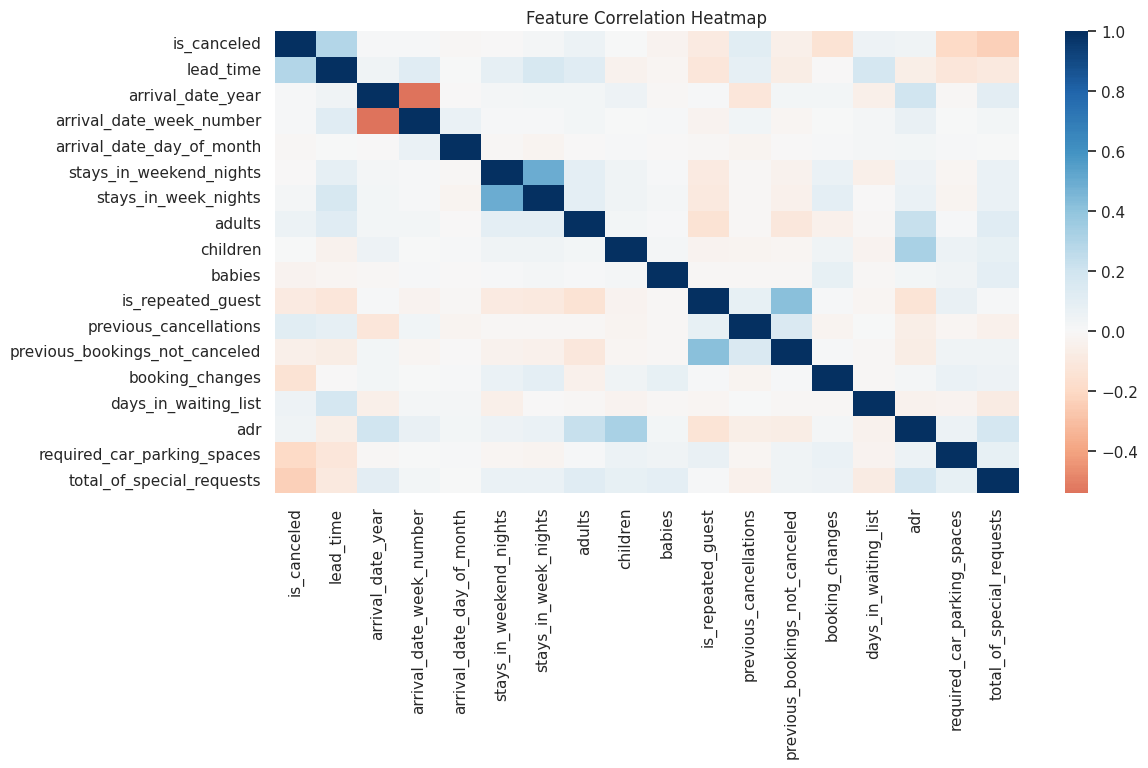

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='RdBu', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

Insight: This validates that lead_time and previous_cancellations
are the strongest positive correlates to a booking being canceled.

In [11]:
# Display core statistics
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363,2016-07-30 00:24:47.883407104
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000,2016-02-01 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000,2016-08-07 00:00:00
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-08 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798,NaN
